In [1]:
import pandas as pd
import numpy as np
print("Versión de pandas:", pd.__version__)
print("Versión de numpy:", np.__version__)

Versión de pandas: 3.0.6
Versión de numpy: 2.5.3


In [2]:
import pandas as pd
import numpy as np

# Creamos un DataFrame desde un diccionario.
# Las claves (nombre, edad, ciudad) serán los nombres de las columnas.
# Las listas serán los datos de cada columna.
datos = {
    "nombre": ["Ana", "Luis", "Marta", "Pedro", "Sofía"],
    "edad":   [28, 34, 22, 45, 31],
    "ciudad": ["Bogotá", "Medellín", "Cali", "Bogotá", "Medellín"],
    "salario": [2500, 3200, 1800, 4100, 2900]
}

df = pd.DataFrame(datos)
df  # Al poner el nombre solo, Jupyter muestra la tabla

,nombre,edad,ciudad,salario
0,Ana,28,Bogotá,2500
1,Luis,34,Medellín,3200
2,Marta,22,Cali,1800
3,Pedro,45,Bogotá,4100
4,Sofía,31,Medellín,2900


In [3]:
df.head()

,nombre,edad,ciudad,salario
0,Ana,28,Bogotá,2500
1,Luis,34,Medellín,3200
2,Marta,22,Cali,1800
3,Pedro,45,Bogotá,4100
4,Sofía,31,Medellín,2900


In [4]:
df.head(2)

,nombre,edad,ciudad,salario
0,Ana,28,Bogotá,2500
1,Luis,34,Medellín,3200


In [5]:
df.tail(3)

,nombre,edad,ciudad,salario
2,Marta,22,Cali,1800
3,Pedro,45,Bogotá,4100
4,Sofía,31,Medellín,2900


In [7]:
df.shape

(5, 4)

In [8]:
df.columns

Index(['nombre', 'edad', 'ciudad', 'salario'], dtype='str')

In [10]:
df.dtypes

nombre       str
edad       int64
ciudad       str
salario    int64
dtype: object

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   nombre   5 non-null      str  
 1   edad     5 non-null      int64
 2   ciudad   5 non-null      str  
 3   salario  5 non-null      int64
dtypes: int64(2), str(2)
memory usage: 292.0 bytes


In [12]:
df.to_csv("personas.csv",index=False)

In [16]:
pd.read_csv("personas.csv").head(2)

,nombre,edad,ciudad,salario
0,Ana,28,Bogotá,2500
1,Luis,34,Medellín,3200


In [17]:
df["nombre"]

0      Ana
1     Luis
2    Marta
3    Pedro
4    Sofía
Name: nombre, dtype: str

In [18]:
df[["nombre", "edad"]]

,nombre,edad
0,Ana,28
1,Luis,34
2,Marta,22
3,Pedro,45
4,Sofía,31


In [19]:
df[df["edad"]>30]

,nombre,edad,ciudad,salario
1,Luis,34,Medellín,3200
3,Pedro,45,Bogotá,4100
4,Sofía,31,Medellín,2900


In [20]:
df[df["ciudad"]=="Bogotá"]

,nombre,edad,ciudad,salario
0,Ana,28,Bogotá,2500
3,Pedro,45,Bogotá,4100


In [21]:
df[(df["edad"]>25)&(df["ciudad"]=="Medellín")]

,nombre,edad,ciudad,salario
1,Luis,34,Medellín,3200
4,Sofía,31,Medellín,2900


In [22]:
df.loc[0,"nombre"]

'Ana'

In [23]:
df.loc[0:2,["nombre","edad"]]

,nombre,edad
0,Ana,28
1,Luis,34
2,Marta,22


In [24]:
df.iloc[0,0]

'Ana'

In [25]:
df.iloc[0:3,0:2]

,nombre,edad
0,Ana,28
1,Luis,34
2,Marta,22


In [27]:
datos = {
    "nombre":["Ana","Luis","Marta","Pedro"],
    "edad":[28,np.nan,22,45],
    "salario": [2500, 3200, np.nan, 4100]
}
df_nulos=pd.DataFrame(datos)
df_nulos

,nombre,edad,salario
0,Ana,28.0,2500.0
1,Luis,NaN,3200.0
2,Marta,22.0,NaN
3,Pedro,45.0,4100.0


In [28]:
df_nulos.isnull()

,nombre,edad,salario
0,False,False,False
1,False,True,False
2,False,False,True
3,False,False,False


In [30]:
df_nulos.isnull().sum()

nombre     0
edad       1
salario    1
dtype: int64

In [31]:
df_nulos.dropna()

,nombre,edad,salario
0,Ana,28.0,2500.0
3,Pedro,45.0,4100.0


In [32]:
df_nulos.dropna(axis=1)

,nombre
0,Ana
1,Luis
2,Marta
3,Pedro


In [33]:
df_nulos.dropna(thresh=2)

,nombre,edad,salario
0,Ana,28.0,2500.0
1,Luis,NaN,3200.0
2,Marta,22.0,NaN
3,Pedro,45.0,4100.0


In [36]:
df_nulos.fillna(0)

,nombre,edad,salario
0,Ana,28.0,2500.0
1,Luis,0.0,3200.0
2,Marta,22.0,0.0
3,Pedro,45.0,4100.0


In [37]:
df_nulos.fillna({"edad":30})

,nombre,edad,salario
0,Ana,28.0,2500.0
1,Luis,30.0,3200.0
2,Marta,22.0,NaN
3,Pedro,45.0,4100.0


In [38]:
df_nulos["edad"].fillna(df_nulos["edad"].mean())

0    28.000000
1    31.666667
2    22.000000
3    45.000000
Name: edad, dtype: float64

In [39]:
df["edad"].mean()      # Promedio
df["salario"].sum()    # Suma total
df["edad"].max()       # Máximo
df["edad"].min()       # Mínimo
df["salario"] * 1.1    # Aumentar 10% a cada salario

0    2750.0
1    3520.0
2    1980.0
3    4510.0
4    3190.0
Name: salario, dtype: float64

In [40]:
df["salario_anual"] = df["salario"] * 12
df.head()

,nombre,edad,ciudad,salario,salario_anual
0,Ana,28,Bogotá,2500,30000
1,Luis,34,Medellín,3200,38400
2,Marta,22,Cali,1800,21600
3,Pedro,45,Bogotá,4100,49200
4,Sofía,31,Medellín,2900,34800


In [41]:
import pandas as pd

# Dataset de ventas.
datos = {
    "vendedor": ["Ana", "Luis", "Ana", "Marta", "Luis", "Ana"],
    "producto": ["Laptop", "Mouse", "Mouse", "Laptop", "Teclado", "Laptop"],
    "precio":   [1200, 25, 30, 1150, 45, 1180],
    "unidades": [1, 4, 3, 2, 5, 1]
}
df = pd.DataFrame(datos)
df

,vendedor,producto,precio,unidades
0,Ana,Laptop,1200,1
1,Luis,Mouse,25,4
2,Ana,Mouse,30,3
3,Marta,Laptop,1150,2
4,Luis,Teclado,45,5
5,Ana,Laptop,1180,1


In [42]:
df.groupby("vendedor")["precio"].sum()

vendedor
Ana      2410
Luis       70
Marta    1150
Name: precio, dtype: int64

In [44]:
df.groupby("vendedor")[["precio","unidades"]].sum()

,precio,unidades
vendedor,,
Ana,2410,5
Luis,70,9
Marta,1150,2


In [45]:
# Suma de precio agrupando por vendedor Y producto
df.groupby(["vendedor", "producto"])["precio"].sum()

vendedor  producto
Ana       Laptop      2380
          Mouse         30
Luis      Mouse         25
          Teclado       45
Marta     Laptop      1150
Name: precio, dtype: int64

In [46]:
resumen = df.groupby("vendedor")["precio"].agg(
    total_ventas="sum",
    promedio="mean",
    maximo="max"
)
resumen

,total_ventas,promedio,maximo
vendedor,,,
Ana,2410,803.333333,1200
Luis,70,35.000000,45
Marta,1150,1150.000000,1150


In [47]:
df.groupby("vendedor").agg({
    "precio": "sum",
    "unidades": ["sum", "mean"]
})

precio unidades          
            sum      sum      mean
vendedor                          
Ana        2410        5  1.666667
Luis         70        9  4.500000
Marta      1150        2  2.000000

In [48]:
# Tabla 1: ventas
ventas = pd.DataFrame({
    "vendedor_id": [1, 2, 1, 3, 2],
    "producto":    ["Laptop", "Mouse", "Mouse", "Laptop", "Teclado"],
    "precio":      [1200, 25, 30, 1150, 45]
})

# Tabla 2: información de vendedores
vendedores = pd.DataFrame({
    "vendedor_id": [1, 2, 3],
    "nombre":      ["Ana", "Luis", "Marta"],
    "ciudad":      ["Bogotá", "Medellín", "Cali"]
})

In [49]:
resultado = pd.merge(ventas, vendedores, on="vendedor_id", how="left")
resultado

,vendedor_id,producto,precio,nombre,ciudad
0,1,Laptop,1200,Ana,Bogotá
1,2,Mouse,25,Luis,Medellín
2,1,Mouse,30,Ana,Bogotá
3,3,Laptop,1150,Marta,Cali
4,2,Teclado,45,Luis,Medellín


In [50]:
# Dos tablas con las mismas columnas
enero = pd.DataFrame({"vendedor": ["Ana", "Luis"], "ventas": [10, 20]})
febrero = pd.DataFrame({"vendedor": ["Ana", "Marta"], "ventas": [15, 25]})

# Apilar verticalmente (una encima de otra)
total = pd.concat([enero, febrero], ignore_index=True)
total

,vendedor,ventas
0,Ana,10
1,Luis,20
2,Ana,15
3,Marta,25


In [51]:
df = pd.DataFrame({
    "producto": ["Laptop", "Mouse", "Teclado"],
    "precio":   [1200, 25, 45],
    "costo":    [900, 12, 20],
    "unidades": [3, 20, 10]
})

# 1. Columna calculada simple
df["ganancia_unitaria"] = df["precio"] - df["costo"]

# 2. Multiplicación
df["ganancia_total"] = df["ganancia_unitaria"] * df["unidades"]

# 3. Columna condicional con np.where → como un IF de Excel
import numpy as np
df["es_rentable"] = np.where(df["ganancia_total"] > 100, "Sí", "No")

# 4. Columna de texto
df["etiqueta"] = df["producto"] + " - " + df["es_rentable"]

df

,producto,precio,costo,unidades,ganancia_unitaria,ganancia_total,es_rentable,etiqueta
0,Laptop,1200,900,3,300,900,Sí,Laptop - Sí
1,Mouse,25,12,20,13,260,Sí,Mouse - Sí
2,Teclado,45,20,10,25,250,Sí,Teclado - Sí


In [52]:
def clasificar(ganancia):
    if ganancia > 5000:
        return "Alta"
    elif ganancia > 1000:
        return "Media"
    else:
        return "Baja"

df["categoria"] = df["ganancia_total"].apply(clasificar)
df

,producto,precio,costo,unidades,ganancia_unitaria,ganancia_total,es_rentable,etiqueta,categoria
0,Laptop,1200,900,3,300,900,Sí,Laptop - Sí,Baja
1,Mouse,25,12,20,13,260,Sí,Mouse - Sí,Baja
2,Teclado,45,20,10,25,250,Sí,Teclado - Sí,Baja


In [53]:
import pandas as pd
import numpy as np

# DataFrame original
ventas = pd.DataFrame({
    "vendedor": ["Ana", "Luis", "Ana", "Marta", "Luis", "Ana", "Marta"],
    "producto": ["Laptop", "Mouse", "Mouse", "Laptop", "Teclado", "Laptop", "Mouse"],
    "precio": [1200, 25, 30, 1150, 45, 1180, 28],
    "unidades": [1, 4, 3, 2, 5, 1, 6]
})

# --- 1. Agrupación ---
# Multiplicamos para obtener el monto por fila y luego agrupamos por vendedor
ventas['monto'] = ventas['precio'] * ventas['unidades']
total_vendedor = ventas.groupby('vendedor')['monto'].sum()

print("1. Dinero total vendido por cada vendedor:")
print(total_vendedor)
print("-" * 50)

# --- 2. Filtrado + agregación ---
# Filtramos el DataFrame original usando la columna 'monto' > 100
ventas_mayores_100 = ventas[ventas['monto'] > 100]
promedio_producto = ventas_mayores_100.groupby('producto')['precio'].mean()

print("2. Promedio de precio por producto (ventas > 100):")
print(promedio_producto)
print("-" * 50)

# --- 3. Columna nueva ---
# La columna 'monto' ya la creamos en el paso 1. Ahora creamos 'categoria' con np.where
ventas['categoria'] = np.where(ventas['monto'] > 500, "Grande", "Pequeña")

print("3. DataFrame con la nueva columna 'categoria':")
print(ventas[['vendedor', 'producto', 'monto', 'categoria']])
print("-" * 50)

# --- 4. Bonus (merge) ---
# Creamos la tabla secundaria con ciudades ficticias
info_vendedor = pd.DataFrame({
    "vendedor": ["Ana", "Luis", "Marta"],
    "ciudad": ["Bogotá", "Medellín", "Cali"]
})

# Unimos con merge usando 'vendedor' como llave común
ventas_final = pd.merge(ventas, info_vendedor, on="vendedor", how="left")

print("4. DataFrame final tras aplicar el Merge:")
print(ventas_final)


1. Dinero total vendido por cada vendedor:
vendedor
Ana      2470
Luis      325
Marta    2468
Name: monto, dtype: int64
--------------------------------------------------
2. Promedio de precio por producto (ventas > 100):
producto
Laptop     1176.666667
Mouse        28.000000
Teclado      45.000000
Name: precio, dtype: float64
--------------------------------------------------
3. DataFrame con la nueva columna 'categoria':
  vendedor producto  monto categoria
0      Ana   Laptop   1200    Grande
1     Luis    Mouse    100   Pequeña
2      Ana    Mouse     90   Pequeña
3    Marta   Laptop   2300    Grande
4     Luis  Teclado    225   Pequeña
5      Ana   Laptop   1180    Grande
6    Marta    Mouse    168   Pequeña
--------------------------------------------------
4. DataFrame final tras aplicar el Merge:
  vendedor producto  precio  unidades  monto categoria    ciudad
0      Ana   Laptop    1200         1   1200    Grande    Bogotá
1     Luis    Mouse      25         4    100   Pequeña

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset de ejemplo
datos = {
    "mes": ["Ene", "Feb", "Mar", "Abr", "May", "Jun"],
    "ventas": [120, 150, 170, 140, 200, 220],
    "gastos": [80, 90, 100, 95, 110, 130],
    "region": ["Norte", "Sur", "Norte", "Sur", "Norte", "Sur"],
    "satisfaccion": [4.1, 4.3, 4.0, 4.5, 4.6, 4.4]
}
df = pd.DataFrame(datos)

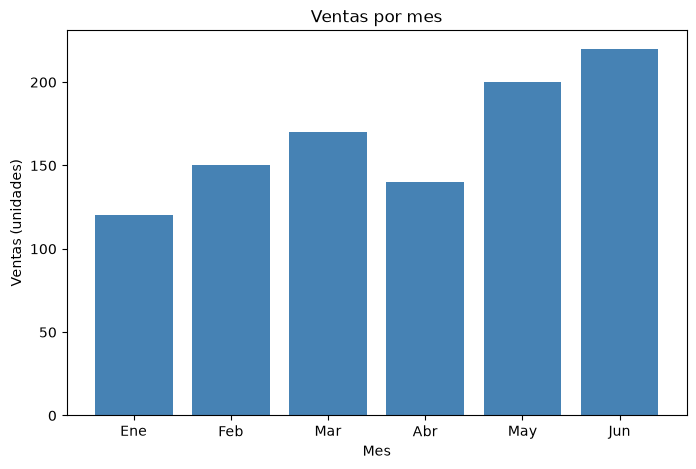

In [55]:
# Con Matplotlib
plt.figure(figsize=(8, 5))
plt.bar(df["mes"], df["ventas"], color="steelblue")
plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas (unidades)")
plt.show()

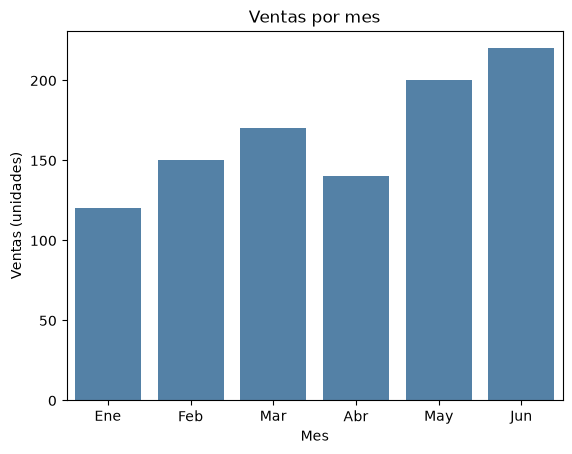

In [56]:
# Con Seaborn (más limpio)
sns.barplot(data=df, x="mes", y="ventas", color="steelblue")
plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas (unidades)")
plt.show()

<Axes: xlabel='mes', ylabel='ventas'>

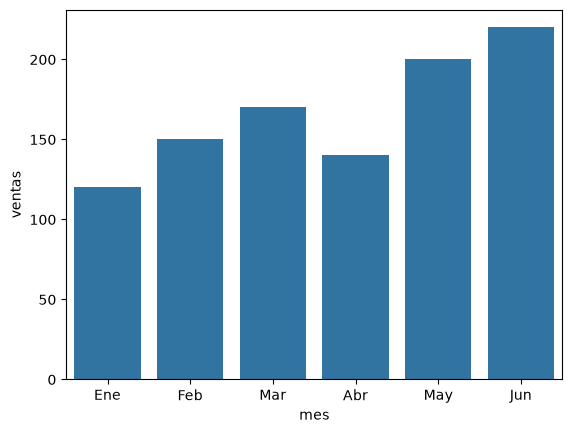

In [57]:
sns.barplot(data=df, x="mes", y="ventas", estimator="sum", errorbar=None)

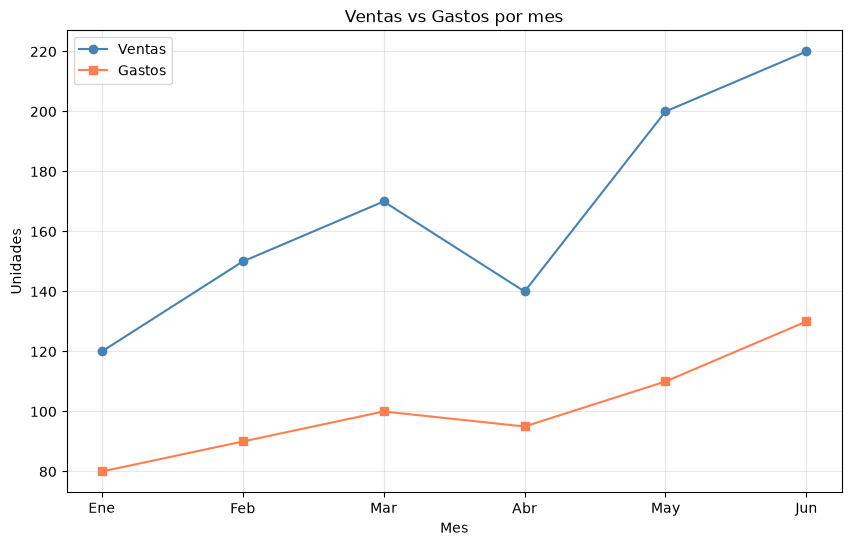

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(df["mes"], df["ventas"], marker="o", label="Ventas", color="steelblue")
plt.plot(df["mes"], df["gastos"], marker="s", label="Gastos", color="coral")
plt.title("Ventas vs Gastos por mes")
plt.xlabel("Mes")
plt.ylabel("Unidades")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

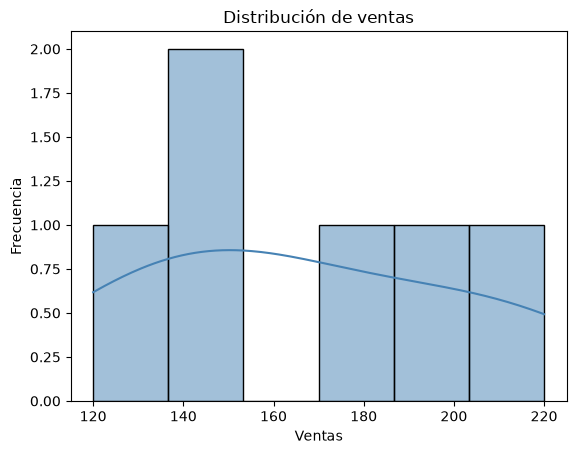

In [59]:
sns.histplot(data=df, x="ventas", bins=6, kde=True, color="steelblue")
plt.title("Distribución de ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()

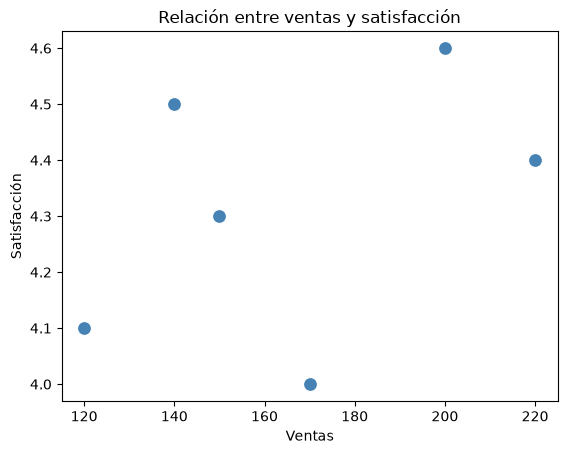

In [60]:
sns.scatterplot(data=df, x="ventas", y="satisfaccion", s=100, color="steelblue")
plt.title("Relación entre ventas y satisfacción")
plt.xlabel("Ventas")
plt.ylabel("Satisfacción")
plt.show()

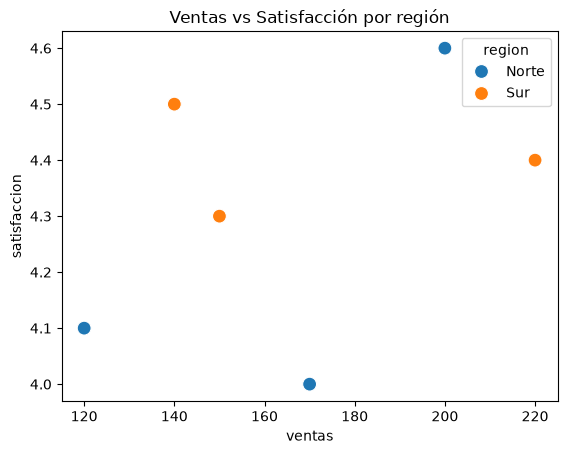

In [61]:
sns.scatterplot(data=df, x="ventas", y="satisfaccion", hue="region", s=100)
plt.title("Ventas vs Satisfacción por región")
plt.show()

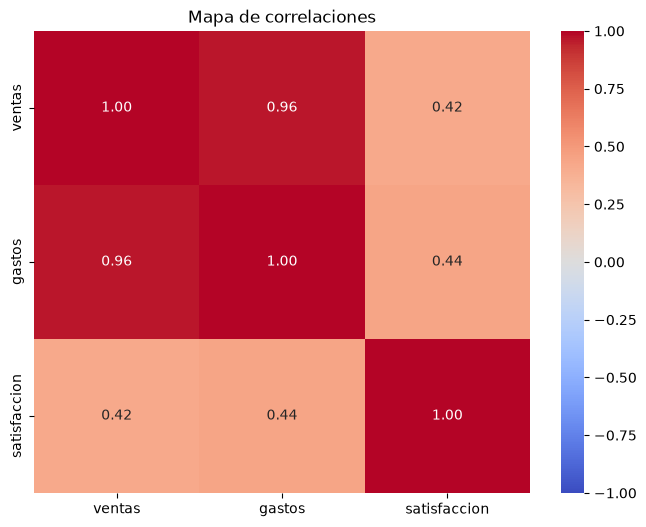

In [62]:
# Calcular la matriz
corr = df[["ventas", "gastos", "satisfaccion"]].corr()

# Dibujar el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0, fmt=".2f")
plt.title("Mapa de correlaciones")
plt.show()

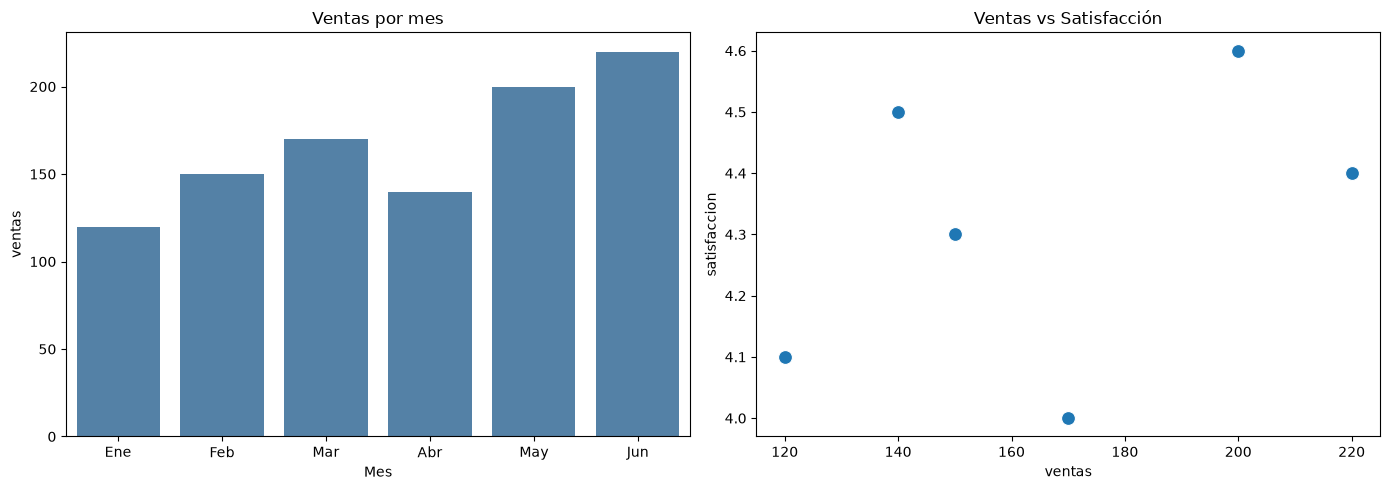

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1
sns.barplot(data=df, x="mes", y="ventas", ax=axes[0], color="steelblue")
axes[0].set_title("Ventas por mes")
axes[0].set_xlabel("Mes")

# Gráfico 2
sns.scatterplot(data=df, x="ventas", y="satisfaccion", ax=axes[1], s=100)
axes[1].set_title("Ventas vs Satisfacción")

plt.tight_layout()   # Ajusta espacios automáticamente
plt.show()

In [64]:
plt.savefig("mi_grafico.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>